# Project-2 #

## Housing Dataset Preprocessing and Skewness reduction ##

### Load Dataset ###

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from scipy.stats import skew

In [4]:
df = pd.read_csv("Housing.csv")
print(df.head())
print("\n")
print("\n")
print(df.info())
print("\n")
print("\n")
print(df.isnull().sum())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 

### Remove Duplicates ###

In [5]:
df.drop_duplicates(inplace=True)
print(df.shape)

(545, 13)


In [6]:
print(df.duplicated().sum())

0


### Encoding ###

#### Binary Encoding ####

In [10]:
binary_cols = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in binary_cols:
    df[col] = df[col].map({"yes":1, "no":0})


#### One- Hot Encoding ####

In [12]:
df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)

KeyError: "None of [Index(['furnishingstatus'], dtype='object')] are in the [columns]"

In [13]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_semi-furnished',
       'furnishingstatus_unfurnished'],
      dtype='object')


### Check Skewness ###

In [14]:
print(df.skew(numeric_only=True))

price                              1.212239
area                               1.321188
bedrooms                           0.495684
bathrooms                          1.589264
stories                            1.082088
mainroad                          -2.065410
guestroom                          1.688419
basement                           0.628590
hotwaterheating                    4.353428
airconditioning                    0.795748
parking                            0.842062
prefarea                           1.254361
furnishingstatus_semi-furnished    0.339635
furnishingstatus_unfurnished       0.741509
dtype: float64


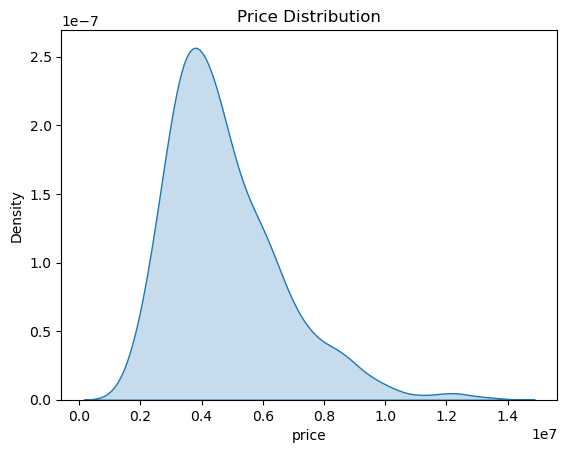

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df["price"], fill=True)

plt.title("Price Distribution")

plt.show()

#### Fix Price and Area ####

In [16]:
df["price"] = np.log1p(df["price"])
df["area"] = np.log1p(df["area"])

In [18]:
print(df[["price","area"]].skew())

price    0.078020
area     0.022972
dtype: float64


In [19]:
print(df.skew(numeric_only=True))

price                              0.078020
area                               0.022972
bedrooms                           0.495684
bathrooms                          1.589264
stories                            1.082088
mainroad                          -2.065410
guestroom                          1.688419
basement                           0.628590
hotwaterheating                    4.353428
airconditioning                    0.795748
parking                            0.842062
prefarea                           1.254361
furnishingstatus_semi-furnished    0.339635
furnishingstatus_unfurnished       0.741509
dtype: float64


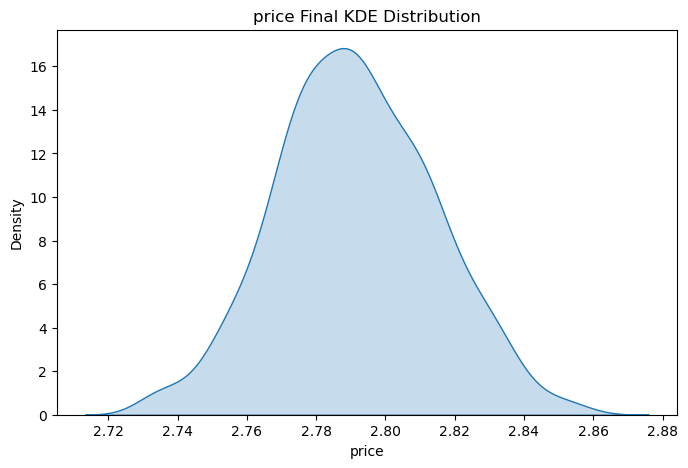

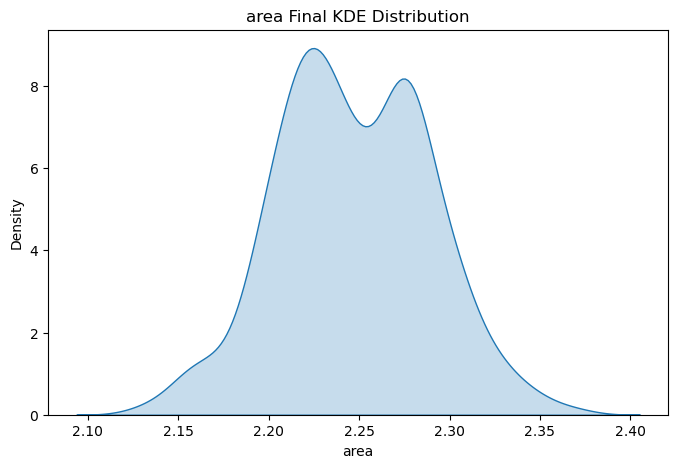

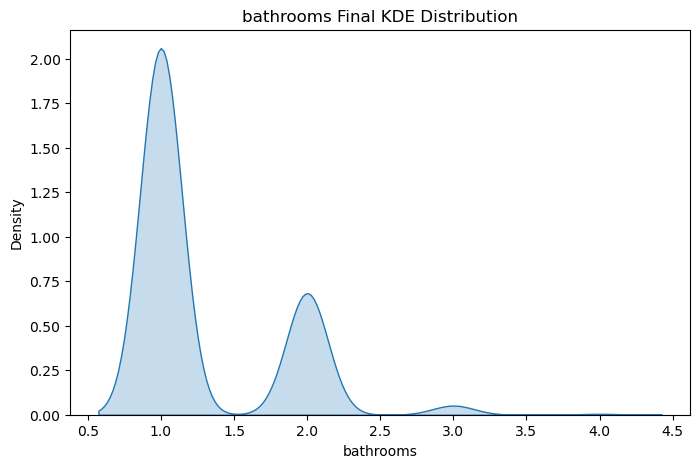

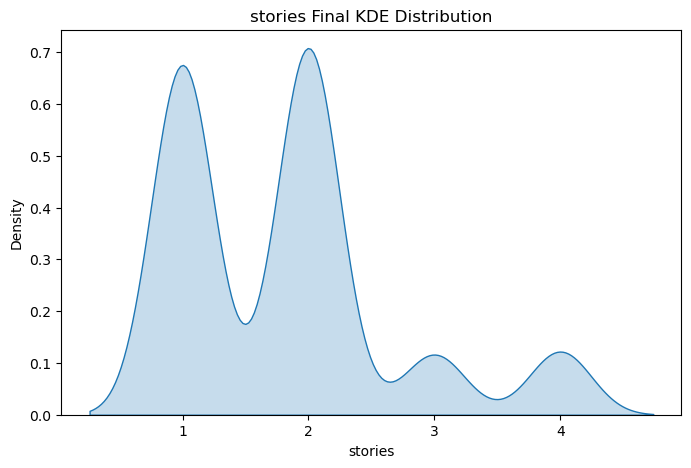

In [21]:
cols = ["price", "area", "bathrooms", "stories"]

for col in cols:

    plt.figure(figsize=(8,5))

    sns.kdeplot(df[col], fill=True)

    plt.title(f"{col} Final KDE Distribution")

    plt.xlabel(col)

    plt.ylabel("Density")

    plt.show()

In [29]:
df["bathrooms"] = np.log1p(df["bathrooms"])

df["stories"] = np.log1p(df["stories"])

In [30]:
print(df[["bathrooms","stories"]].skew())

bathrooms    1.202906
stories      0.207684
dtype: float64


In [31]:
print(df.skew(numeric_only=True))

price                              0.078020
area                               0.022972
bedrooms                           0.495684
bathrooms                          1.202906
stories                            0.207684
mainroad                          -2.065410
guestroom                          1.688419
basement                           0.628590
hotwaterheating                    4.353428
airconditioning                    0.795748
parking                            0.842062
prefarea                           1.254361
furnishingstatus_semi-furnished    0.339635
furnishingstatus_unfurnished       0.741509
dtype: float64
